# Diagnostic: Why is Paediatric MIC_90 flat 2007–2017?

The EDA showed paediatric MIC_90 stuck at ~0.125 mg/L from 2006 to 2016,
then a sudden jump to 32 mg/L in 2019. This notebook investigates why.

**Hypotheses to test:**
1. Very few paediatric isolates → MIC_90 unreliable (small n)
2. Geographic bias → only low-resistance countries report paediatric data
3. Censoring floor → 0.125 mg/L is the panel floor, all values hit it
4. True biology → paediatric isolates genuinely more susceptible in those years

In [9]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path('../')
sys.path.insert(0, str(project_root / 'src'))

from data.loader import ATLASLoader
from data.preprocessor import MICPreprocessor

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (13, 5), 'figure.dpi': 100})
EUCAST_R = 8

In [10]:
loader = ATLASLoader(project_root / 'data' / 'raw')
df_raw = loader.load('Klebsiella pneumoniae', antibiotic='Meropenem')

df = df_raw.copy()
parsed = df['Meropenem'].apply(
    lambda x: MICPreprocessor.parse_censored_mic(x) if pd.notna(x) else (None, None)
)
df['mic_value']   = parsed.apply(lambda t: t[0])
df['mic_operator']= parsed.apply(lambda t: t[1])
df = df[df['mic_value'].notna() & (df['mic_value'] > 0)].copy()
df['mic_log2']    = np.log2(df['mic_value'])
df['is_censored'] = df['mic_operator'].isin(['>', '<', '>=', '<='])

paeds = df[df['Age Group'] == '0 - 17'].copy()
print(f'Total K. pneumoniae Meropenem rows: {len(df):,}')
print(f'Paediatric (0-17) rows:             {len(paeds):,}  ({len(paeds)/len(df)*100:.1f}%)')

Total K. pneumoniae Meropenem rows: 100,875
Paediatric (0-17) rows:             8,508  (8.4%)


## Hypothesis 1 — Is n too small to trust MIC_90?

Year      N   MIC_50   MIC_90   %Cens
----------------------------------------
2004      5    0.030    0.084    80.0% ← LOW N
2005      8    0.030    9.684    87.5% ← LOW N
2006    127    0.030    1.000    58.3%
2007    387    0.030    0.172    81.7%
2008    478    0.030    0.120    90.6%
2009    431    0.030    0.120    90.0%
2010    318    0.030    0.120    87.7%
2011    182    0.030    0.120    89.6%
2012    322    0.030    0.120    54.7%
2013    480    0.030    0.120    36.2%
2014    549    0.030    0.120    31.7%
2015    564    0.030    0.120    35.8%
2016    658    0.060    0.120    31.0%
2017    508    0.030    0.120    25.2%
2018    416    0.030    2.000    89.4%
2019    539    0.030   32.000    90.2%
2020    597    0.030   16.000    90.1%
2021    729    0.030   32.000    89.8%
2022    377    0.030   16.000    81.2%
2023    331    0.030   16.000    83.4%
2024    502    0.030   32.000    91.0%


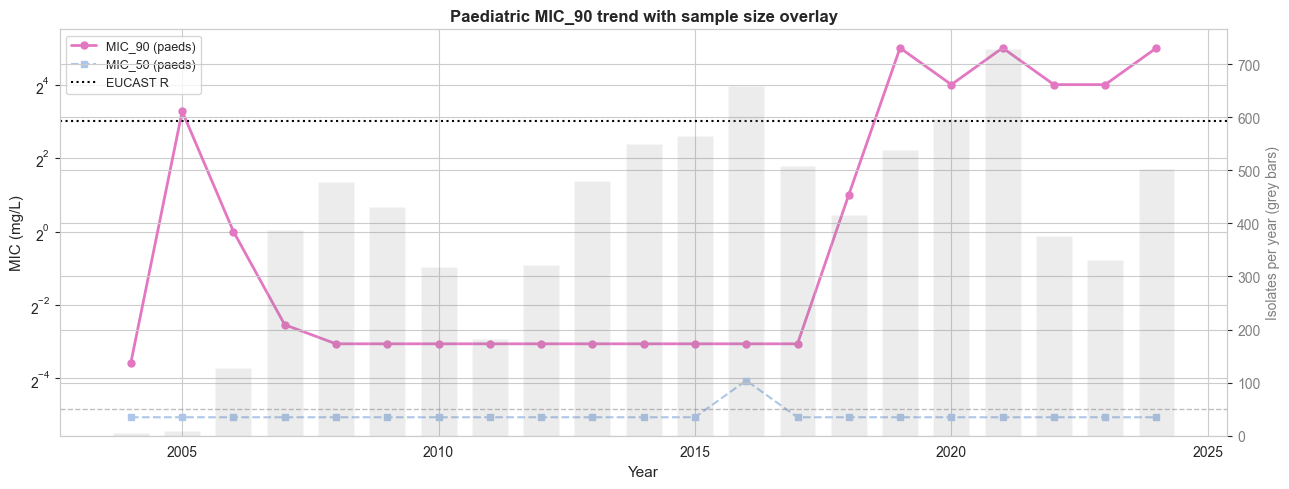

In [11]:
paeds_yr = paeds.groupby('Year').agg(
    n        = ('mic_value', 'count'),
    mic50    = ('mic_value', lambda x: x.quantile(0.50)),
    mic90    = ('mic_value', lambda x: x.quantile(0.90)),
    pct_cens = ('is_censored', 'mean'),
).reset_index()
paeds_yr['pct_cens'] *= 100

print(f"{'Year':>4}  {'N':>5}  {'MIC_50':>7}  {'MIC_90':>7}  {'%Cens':>6}")
print('-' * 40)
for _, r in paeds_yr.iterrows():
    flag = ' ← LOW N' if r.n < 50 else ''
    print(f"{int(r.Year):4d}  {int(r.n):5,}  {r.mic50:7.3f}  {r.mic90:7.3f}  {r.pct_cens:6.1f}%{flag}")

fig, ax1 = plt.subplots()
ax1.plot(paeds_yr['Year'], paeds_yr['mic90'], 'o-', color='#e377c2', lw=2, ms=5, label='MIC_90 (paeds)')
ax1.plot(paeds_yr['Year'], paeds_yr['mic50'], 's--', color='#aec7e8', lw=1.5, ms=4, label='MIC_50 (paeds)')
ax1.axhline(EUCAST_R, color='black', linestyle=':', lw=1.5, label='EUCAST R')
ax1.set_yscale('log', base=2)
ax1.set_ylabel('MIC (mg/L)', fontsize=11)
ax1.set_xlabel('Year', fontsize=11)
ax1.legend(loc='upper left', fontsize=9)
ax1.set_title('Paediatric MIC_90 trend with sample size overlay', fontsize=12, fontweight='bold')

ax2 = ax1.twinx()
ax2.bar(paeds_yr['Year'], paeds_yr['n'], alpha=0.15, color='grey', width=0.7)
ax2.axhline(50, color='grey', linestyle='--', lw=1, alpha=0.5)
ax2.set_ylabel('Isolates per year (grey bars)', fontsize=10, color='grey')
ax2.tick_params(axis='y', labelcolor='grey')
plt.tight_layout()
plt.show()

## Hypothesis 2 — Geographic bias in paediatric reporting

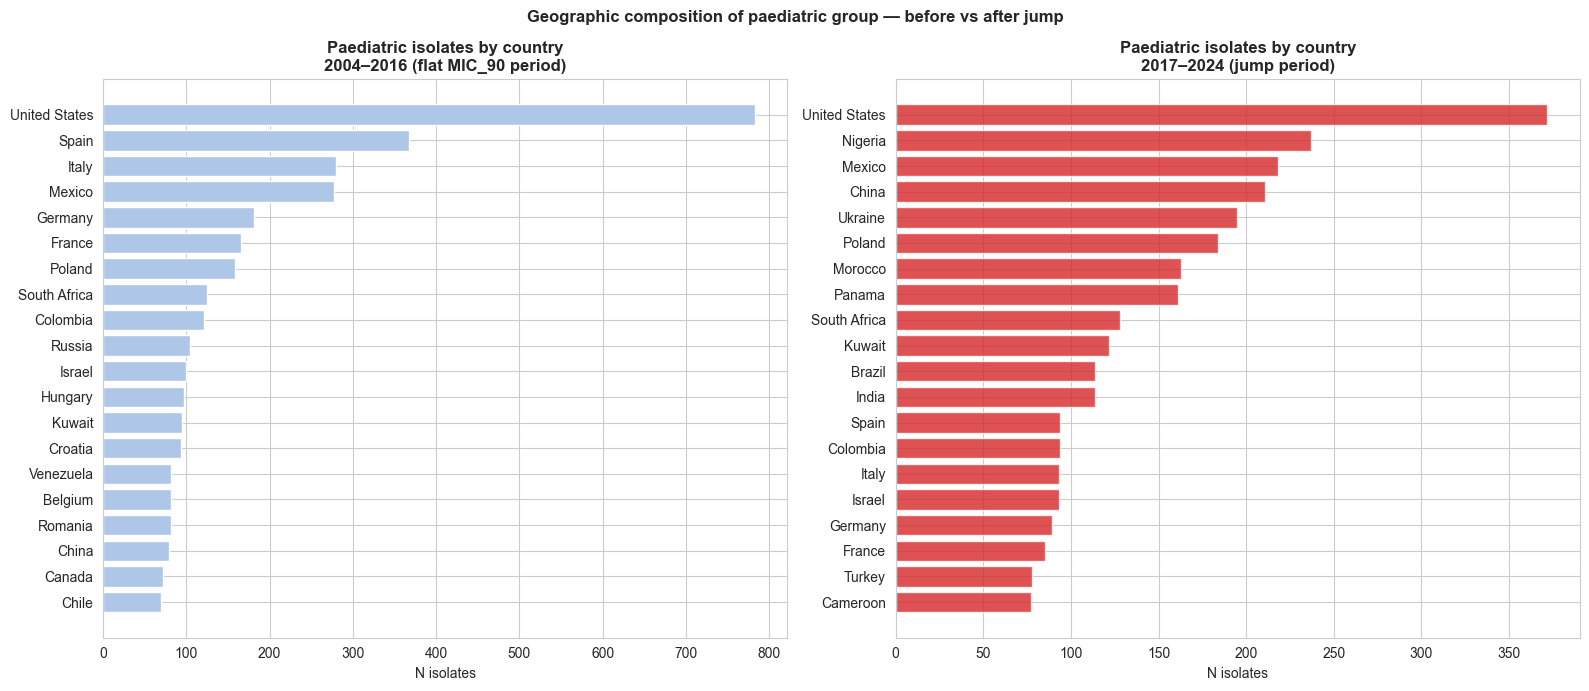

Countries appearing only post-2017 (10): ['Cameroon', 'Costa Rica', 'Dominican Republic', 'Ghana', 'Ivory Coast', 'Malawi', 'New Zealand', 'Qatar', 'Uganda', 'Ukraine']


In [12]:
# Countries contributing paediatric isolates — early period vs late period
early = paeds[paeds['Year'].between(2004, 2016)]
late  = paeds[paeds['Year'].between(2017, 2024)]

early_ctry = early['Country'].value_counts().head(20)
late_ctry  = late['Country'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(early_ctry.index[::-1], early_ctry.values[::-1], color='#aec7e8')
axes[0].set_title('Paediatric isolates by country\n2004–2016 (flat MIC_90 period)', fontweight='bold')
axes[0].set_xlabel('N isolates')

axes[1].barh(late_ctry.index[::-1], late_ctry.values[::-1], color='#d62728', alpha=0.8)
axes[1].set_title('Paediatric isolates by country\n2017–2024 (jump period)', fontweight='bold')
axes[1].set_xlabel('N isolates')

plt.suptitle('Geographic composition of paediatric group — before vs after jump', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Countries present in late but NOT early period
new_countries = set(late['Country'].unique()) - set(early['Country'].unique())
print(f'Countries appearing only post-2017 ({len(new_countries)}): {sorted(new_countries)}')

## Hypothesis 3 — Is 0.125 the censoring floor?

If all values in 2007–2016 are reported as `<=0.125`, then the MIC_90 of 0.125
is just the panel floor repeated — not a biological signal.

In [13]:
flat_period = paeds[paeds['Year'].between(2007, 2016)]

print('Raw Meropenem value distribution for paediatric 2007-2016 (top 20):')
print(flat_period['Meropenem'].value_counts().head(20).to_string())
print(f'\nParsed MIC_90 = {flat_period["mic_value"].quantile(0.90):.4f} mg/L')
print(f'Censored values: {flat_period["is_censored"].mean()*100:.1f}%')
print(f'Values at 0.125 or below: {(flat_period["mic_value"] <= 0.125).mean()*100:.1f}%')

Raw Meropenem value distribution for paediatric 2007-2016 (top 20):
Meropenem
<=0.06     2399
0.06        645
0.03        616
0.12        330
0.25         81
>16          57
>8           49
0.5          42
8            33
4            31
1            29
2            26
16           15
0.015        12
<=0.004       4

Parsed MIC_90 = 0.1200 mg/L
Censored values: 57.4%
Values at 0.125 or below: 91.7%


## Hypothesis 4 — Are paediatric isolates genuinely more susceptible?

Compare paediatric vs adult resistance rate in the same years and countries.

In [14]:
df['age_simple'] = 'Other'
df.loc[df['Age Group'] == '0 - 17', 'age_simple'] = 'Paediatric'
df.loc[df['Age Group'].isin(['18 - 30', '31 - 60', '61+']), 'age_simple'] = 'Adult/Elderly'

# Same countries in both groups during 2007-2016
flat_years = df[df['Year'].between(2007, 2016)]
shared_countries = (
    set(flat_years[flat_years['age_simple']=='Paediatric']['Country'].unique())
    & set(flat_years[flat_years['age_simple']=='Adult/Elderly']['Country'].unique())
)
print(f'Countries with BOTH paediatric and adult data in 2007-2016: {len(shared_countries)}')

controlled = flat_years[flat_years['Country'].isin(shared_countries)]
comparison = controlled.groupby('age_simple').agg(
    n              = ('mic_value', 'count'),
    mic90          = ('mic_value', lambda x: x.quantile(0.90)),
    pct_resistant  = ('mic_value', lambda x: (x >= EUCAST_R).mean()),
    pct_censored   = ('is_censored', 'mean'),
)
comparison['pct_resistant'] *= 100
comparison['pct_censored']  *= 100
print('\nControlled comparison (same countries, 2007-2016):')
print(comparison.to_string(float_format='{:.3f}'.format))

Countries with BOTH paediatric and adult data in 2007-2016: 63

Controlled comparison (same countries, 2007-2016):
                   n  mic90  pct_resistant  pct_censored
age_simple                                              
Adult/Elderly  45064  0.500          6.493        52.128
Other            670  1.000          7.463        65.821
Paediatric      4369  0.120          3.525        57.427


## Military proxy — countries and filter details

In [15]:
WOUND_SOURCES = {'Wound', 'Abscess', 'Skin and Soft Tissue'}

df['military_proxy'] = (
    df['Source'].isin(WOUND_SOURCES)
    & (df['Gender'] == 'Male')
    & (df['Age Group'].isin(['18 - 30', '31 - 60']))
)

mil = df[df['military_proxy']]
print(f'Military proxy isolates: {len(mil):,}  ({len(mil)/len(df)*100:.2f}% of dataset)')
print(f'\nFilters applied:')
print(f'  Source in {WOUND_SOURCES}')
print(f'  Gender = Male')
print(f'  Age Group in 18-30, 31-60')

print(f'\nSource breakdown:')
print(mil['Source'].value_counts().to_string())

print(f'\nTop 20 contributing countries:')
ctry_counts = mil['Country'].value_counts().head(20)
for country, n in ctry_counts.items():
    print(f'  {country:<30} {n:>5,}  ({n/len(mil)*100:.1f}%)')

# N per year
mil_yr_n = mil.groupby('Year').size().reset_index(name='n')
print(f'\nN per year (threshold=50 for reliable MIC_90):')
for _, r in mil_yr_n.iterrows():
    flag = '' if r.n >= 50 else '  <- unreliable'
    print(f'  {int(r.Year)}: n={int(r.n)}{flag}')

Military proxy isolates: 2,813  (2.79% of dataset)

Filters applied:
  Source in {'Wound', 'Abscess', 'Skin and Soft Tissue'}
  Gender = Male
  Age Group in 18-30, 31-60

Source breakdown:
Source
Wound      2265
Abscess     548

Top 20 contributing countries:
  United States                    350  (12.4%)
  Spain                            142  (5.0%)
  Mexico                           141  (5.0%)
  India                            111  (3.9%)
  Germany                          105  (3.7%)
  Philippines                      101  (3.6%)
  Russia                            98  (3.5%)
  Italy                             89  (3.2%)
  China                             85  (3.0%)
  Israel                            78  (2.8%)
  Taiwan                            73  (2.6%)
  Kuwait                            69  (2.5%)
  Portugal                          69  (2.5%)
  South Africa                      68  (2.4%)
  Nigeria                           68  (2.4%)
  Greece                          

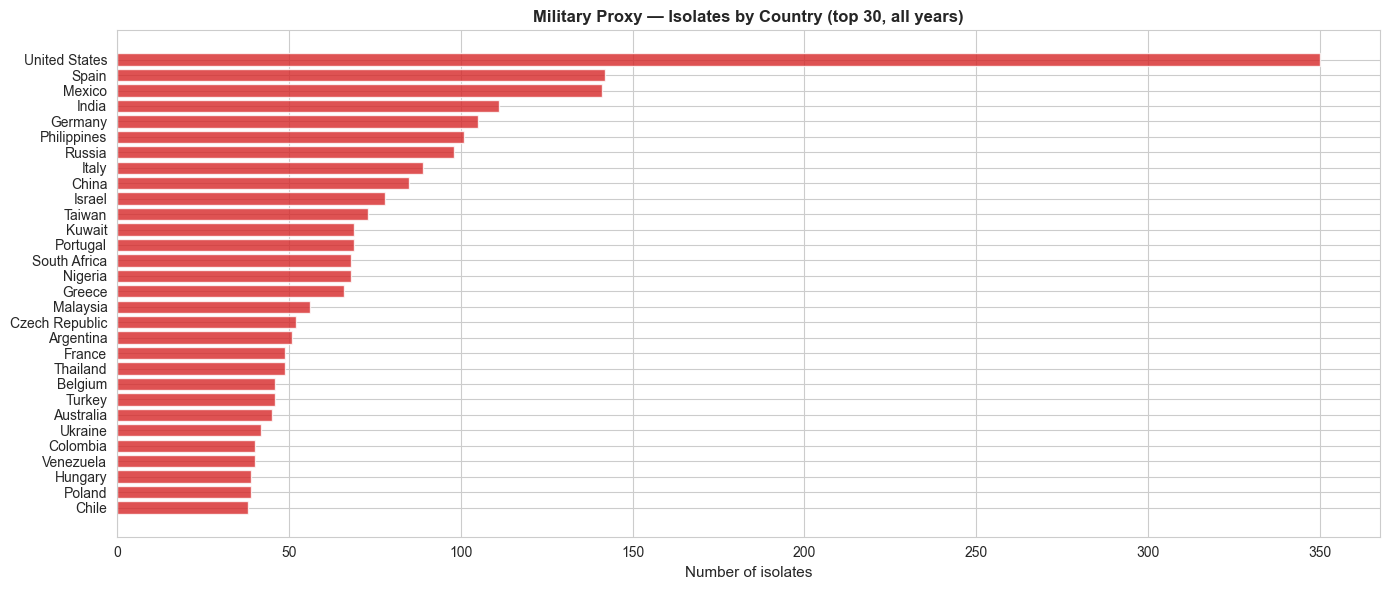

In [16]:
# Country map of military proxy
ctry_all = mil['Country'].value_counts().reset_index()
ctry_all.columns = ['Country', 'n']

fig, ax = plt.subplots(figsize=(14, 6))
top30 = ctry_all.head(30)
ax.barh(top30['Country'][::-1], top30['n'][::-1], color='#d62728', alpha=0.8)
ax.set_xlabel('Number of isolates', fontsize=11)
ax.set_title('Military Proxy — Isolates by Country (top 30, all years)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary of findings

Fill in after running the cells above. Key questions to answer:

- **H1**: Is n < 50 for paediatric in 2007–2016? If yes, MIC_90 is statistically unreliable.
- **H2**: Do high-resistance countries (Turkey, Ukraine, India) appear only post-2017? If yes, the jump is a geographic enrollment artifact.
- **H3**: Are >90% of paediatric values `<=0.125` in 2007–2016? If yes, the flat line is the censoring floor.
- **H4**: Is the adult resistance rate also low in the same countries/years? If yes, the low paediatric MIC reflects true susceptibility in those geographies.

**Action**: whichever hypothesis is confirmed, document it in `reports/atlas_eda_analysis.md` and decide whether to include/exclude paediatric group in the model.